In [1]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_notebook import *
from syn_project.utils_analyse import *

%matplotlib widget

In [2]:
condition = "control"
data = "biased_80"
switch_epoch = 0
checkpoint_epoch = 0

n_samples = 1000
show_results_fusion = True
fusion_attr_weight = 1.0
noise = 0.0

project_name = "syn"
experiment_name = get_experiment_name(condition, data, switch_epoch)

training_params = get_training_params(project_name, experiment_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

global_workspace = get_global_workspace(project_name, experiment_name, epoch=checkpoint_epoch)
data_module = get_data_module(project_name,  experiment_name)
test_samples = get_data_samples(data_module, n_samples, noise=  noise, split= "test")
data_translated = get_data_translated(global_workspace, test_samples, n_samples, fusion_attr_weight, show_results_fusion)

/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/control_biased_80/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/control_biased_80/checkpoints/last.ckpt


/home/lucas/gwsyn/syn_project/utils_analyse.py:91: UserWarning: Empty mask detected; using full image for color extraction
  warnings.warn("Empty mask detected; using full image for color extraction")


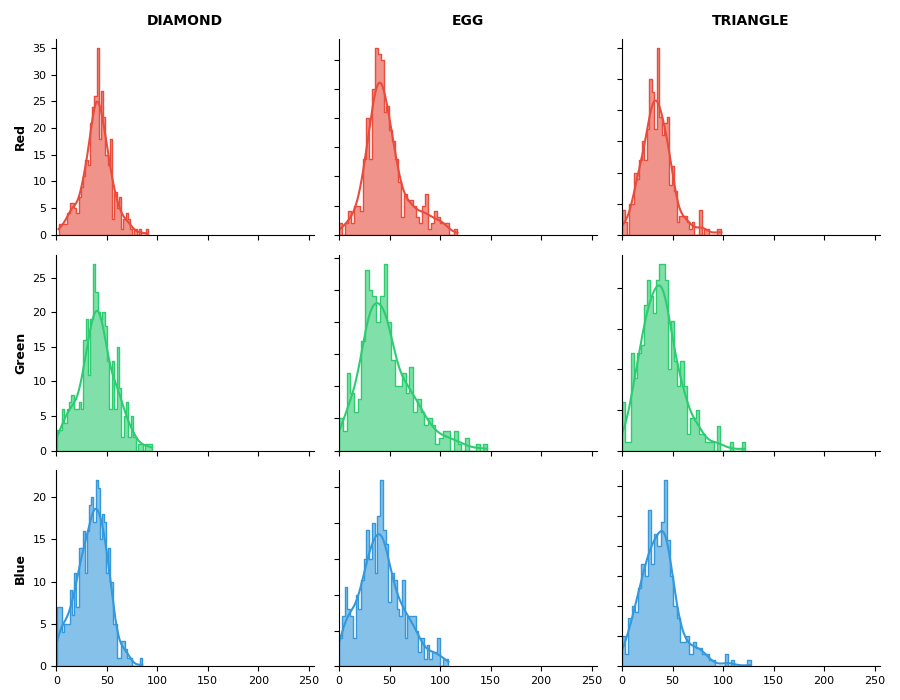

In [3]:
masks = get_mask_from_shape_batch(data_translated["train_images"])
masks_decoded = get_mask_from_shape_batch(data_translated["images_decoded"])

colors_from_training_attr = get_color_from_attr_batch(data_translated['train_attr'])
colors_from_training_img = get_color_from_img_batch(data_translated["train_images"], masks)
colors_from_decoded_img = get_color_from_img_batch(data_translated["images_decoded"], masks_decoded)

categories_from_training_attr = data_translated['train_attr'][:, 0:3]
categories_from_decoded_attr = categorize_decoded_attr(data_translated["attr_decoded"])

categories_indices = categories_from_decoded_attr.argmax(dim=1).detach().cpu().numpy()
rgb_arrays = colors_from_decoded_img
colors_np = np.vstack(rgb_arrays)

stats = get_color_stats_per_category(colors_np, categories_indices)

fig = plot_rgb_distribution(colors_np, categories_indices)
plt.show()


In [ ]:
y = categories_from_training_attr.argmax(dim=1).detach().cpu().numpy()
y_pred = categories_from_decoded_attr.argmax(dim=1).detach().cpu().numpy()

acc, errors = get_attr_classification_stats(y, y_pred)

In [34]:
import wandb
import pandas as pd

api = wandb.Api()

# 1. Accéder au run spécifique
# Format : "pseudo/nom-du-projet/run_id"
# Le run_id est le code de 8 caractères (ex: 'a1b2c3d4') dans l'URL de ton run
run = api.run("lchaigne-universit-montpellier/syn/o1tyref6")

# 2. Récupérer l'historique complet
# .history() retourne par défaut un échantillon, 
# pour TOUT avoir, on utilise pandas_lot=True
history_df = run.history()


# Tu peux maintenant faire :
# history_df.to_csv("mon_analyse_couleurs.csv")

In [44]:
a = np.load("/home/lucas/gwsyn/checkpoints/syn/test_biased_80_switch_600/checkpoints/stats_epoch_005.npz")

In [48]:
a["colors_from_data_attr"]

array([[  0,   4,  92],
       [145,   1, 146],
       [  0, 203,  25],
       ...,
       [109, 120, 254],
       [218, 227, 206],
       [182, 254, 125]], dtype=uint8)